# Fuzzy C-Means sur Digits

**Dataset** : `sklearn.datasets.load_digits` - 1797 images 8x8, 10 classes
**Objectif** : clustering non supervisé avec Fuzzy C-Means, sélection par validation puis évaluation sur test
**Librairies** : `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `scikit-fuzzy`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

try:
    import skfuzzy as fuzz
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-fuzzy', '-q'])
    import skfuzzy as fuzz

np.random.seed(42)

Dataset complet: 1797 echantillons, 64 variables
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Valeurs pixel min/max: 0.0 / 16.0
Train: 1257 | Validation: 270 | Test: 270
Variance expliquee PCA 2D: 0.220
Variance expliquee PCA 20D: 0.800


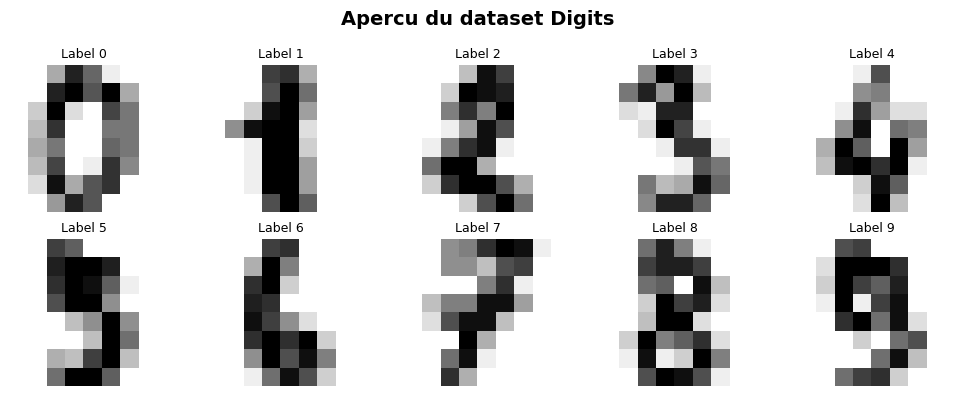

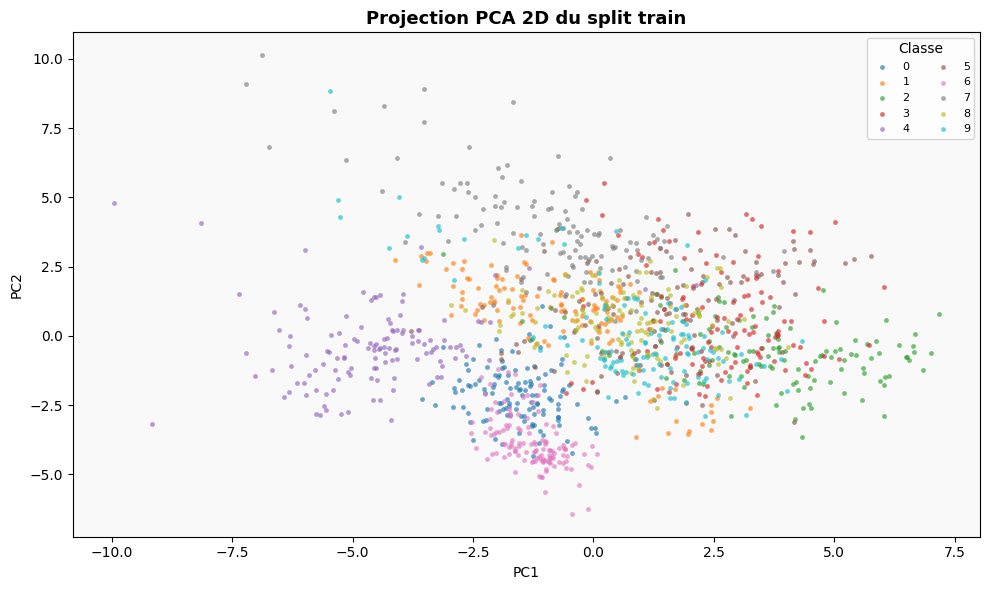

In [2]:
# Chargement du dataset Digits
digits = load_digits()
X_raw = digits.data.astype(float)
y_raw = digits.target.astype(int)

print(f'Dataset complet: {X_raw.shape[0]} echantillons, {X_raw.shape[1]} variables')
print(f'Classes: {np.unique(y_raw).tolist()}')
print(f'Valeurs pixel min/max: {X_raw.min():.1f} / {X_raw.max():.1f}')

# Split train 70%, validation 15%, test 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw,
    test_size=0.30,
    stratify=y_raw,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f'Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# Standardisation sur train uniquement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
X_val_pca2 = pca_2d.transform(X_val_scaled)
X_test_pca2 = pca_2d.transform(X_test_scaled)

# PCA pour clustering
pca_nd_components = 20
pca_nd = PCA(n_components=pca_nd_components, random_state=42)
X_train_pca_nd = pca_nd.fit_transform(X_train_scaled)
X_val_pca_nd = pca_nd.transform(X_val_scaled)
X_test_pca_nd = pca_nd.transform(X_test_scaled)

print(f'Variance expliquee PCA 2D: {pca_2d.explained_variance_ratio_.sum():.3f}')
print(f'Variance expliquee PCA {pca_nd_components}D: {pca_nd.explained_variance_ratio_.sum():.3f}')

# Apercu de quelques images du dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 4), facecolor='white')
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[idx], cmap='gray_r')
    ax.set_title(f'Label {digits.target[idx]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Apercu du dataset Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Projection PCA 2D coloree par vraie classe
class_colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
for cls in np.unique(y_train):
    mask = y_train == cls
    ax.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1], s=12, alpha=0.65, label=str(cls), color=class_colors[cls], linewidths=0)

ax.set_title('Projection PCA 2D du split train', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Classe', ncol=2, fontsize=8, loc='upper right')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [3]:
# Tuning Fuzzy C-Means: random search continu + validation
ari_min = 0.20
nmi_min = 0.20
n_internal_splits = 5
max_evaluations = 80
min_valid_splits = 3
bad_splits_limit = 3

rng = np.random.default_rng(42)

# Intervalles continus
c_range = (8, 13)
m_range = (1.40, 2.40)
error_range = (1e-5, 1e-3)
maxiter_range = (150, 400)

candidate_params = []
for _ in range(max_evaluations):
    candidate_params.append({
        'c': int(rng.integers(c_range[0], c_range[1])),
        'm': float(rng.uniform(*m_range)),
        'error': float(10 ** rng.uniform(np.log10(error_range[0]), np.log10(error_range[1]))),
        'maxiter': int(rng.integers(maxiter_range[0], maxiter_range[1])),
        'seed': int(rng.integers(1, 5000))
    })

print('Intervalles de tuning proposes')
print(f'c: [{c_range[0]} .. {c_range[1]-1}]')
print(f'm: [{m_range[0]:.2f} .. {m_range[1]:.2f}]')
print(f'error: [{error_range[0]:.0e} .. {error_range[1]:.0e}]')
print(f'maxiter: [{maxiter_range[0]} .. {maxiter_range[1]-1}]')
print(f'Nombre de combinaisons teste: {len(candidate_params)}')
print(f'Multi-splits internes: {n_internal_splits}')
print(f'Splits valides minimum requis: {min_valid_splits}')
print(f'Arret anticipe apres {bad_splits_limit} splits sous seuils')
print(f'Filtre minimum validation ARI: {ari_min}')
print(f'Filtre minimum validation NMI: {nmi_min}')
print()


def crisp_labels_from_membership(u):
    return np.argmax(u, axis=0)


def evaluate_split(name, X, y_true, labels):
    n_clusters = len(np.unique(labels))
    print(name)
    print(f'Clusters detectes: {n_clusters}')

    if n_clusters < 2:
        print('Metriques non disponibles: pas assez de clusters valides')
        print()
        return {
            'n_clusters': n_clusters,
            'ari': np.nan,
            'nmi': np.nan,
            'silhouette': np.nan,
            'valid': False
        }

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    sil = silhouette_score(X, labels, sample_size=min(1000, len(X)), random_state=42)

    print(f'ARI: {ari:.4f}')
    print(f'NMI: {nmi:.4f}')
    print(f'Silhouette: {sil:.4f}')
    print()

    return {
        'n_clusters': n_clusters,
        'ari': ari,
        'nmi': nmi,
        'silhouette': sil,
        'valid': True
    }


def validation_score(metrics, ari_minimum, nmi_minimum):
    if not metrics['valid']:
        return -1e9, False, 'invalid_metrics'

    if metrics['ari'] < ari_minimum or metrics['nmi'] < nmi_minimum:
        return -1e6 + metrics['ari'] + metrics['nmi'], False, 'below_thresholds'

    cluster_alignment = 1 - min(abs(metrics['n_clusters'] - 10), 10) / 10
    sil_norm = (metrics['silhouette'] + 1.0) / 2.0
    score = 0.40 * metrics['ari'] + 0.30 * metrics['nmi'] + 0.20 * sil_norm + 0.10 * cluster_alignment
    return score, True, 'eligible'


X_pool = np.vstack([X_train_pca_nd, X_val_pca_nd])
y_pool = np.concatenate([y_train, y_val])

splitter = StratifiedShuffleSplit(n_splits=n_internal_splits, test_size=0.25, random_state=42)
split_indices = list(splitter.split(X_pool, y_pool))

results = []
total = len(candidate_params)

for trial, params in enumerate(candidate_params, start=1):
    c = params['c']
    m = params['m']
    error = params['error']
    maxiter = params['maxiter']
    seed = params['seed']

    split_aris = []
    split_nmis = []
    split_sils = []
    split_clusters = []
    valid_split_count = 0
    bad_split_count = 0

    for tr_idx, va_idx in split_indices:
        X_tr, X_va = X_pool[tr_idx], X_pool[va_idx]
        y_va = y_pool[va_idx]

        cntr, u_tr, _, _, _, _, _ = fuzz.cluster.cmeans(
            X_tr.T,
            c=c,
            m=m,
            error=error,
            maxiter=maxiter,
            init=None,
            seed=seed
        )

        labels_tr = crisp_labels_from_membership(u_tr)
        if len(np.unique(labels_tr)) < 2:
            continue

        u_va, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X_va.T,
            cntr,
            m=m,
            error=error,
            maxiter=maxiter,
            init=None,
            seed=seed
        )
        labels_va = crisp_labels_from_membership(u_va)

        if len(np.unique(labels_va)) < 2:
            continue

        ari = adjusted_rand_score(y_va, labels_va)
        nmi = normalized_mutual_info_score(y_va, labels_va)
        sil = silhouette_score(X_va, labels_va, sample_size=min(1000, len(X_va)), random_state=42)

        split_aris.append(ari)
        split_nmis.append(nmi)
        split_sils.append(sil)
        split_clusters.append(len(np.unique(labels_va)))
        valid_split_count += 1

        if ari < ari_min or nmi < nmi_min:
            bad_split_count += 1
            if valid_split_count >= min_valid_splits and bad_split_count >= bad_splits_limit:
                break

    if valid_split_count < min_valid_splits:
        print(f'Essai {trial}/{total}: splits valides insuffisants ({valid_split_count}) -> rejete')
        continue

    metrics_val = {
        'n_clusters': int(np.round(np.mean(split_clusters))),
        'ari': float(np.mean(split_aris)),
        'nmi': float(np.mean(split_nmis)),
        'silhouette': float(np.mean(split_sils)),
        'ari_std': float(np.std(split_aris)),
        'nmi_std': float(np.std(split_nmis)),
        'silhouette_std': float(np.std(split_sils)),
        'valid': True,
        'valid_split_count': valid_split_count
    }

    score_val, eligible_val, eligibility_reason = validation_score(metrics_val, ari_min, nmi_min)

    results.append({
        'trial': trial,
        'params': params,
        'score_val': float(score_val),
        'eligible_val': bool(eligible_val),
        'eligibility_reason': eligibility_reason,
        'metrics_val': metrics_val
    })

    status = 'eligible' if eligible_val else 'rejete'
    print(f"Essai {trial}/{total} score={score_val:.4f} {status} | c={c} | m={m:.2f} | err={error:.1e} | maxiter={maxiter} | splits={valid_split_count}")

if len(results) == 0:
    raise ValueError('Aucune combinaison exploitable n a ete evaluee.')

eligible_results = [r for r in results if r['eligible_val']]
if len(eligible_results) > 0:
    results_sorted = sorted(eligible_results, key=lambda x: x['score_val'], reverse=True)
    print(f"Combinaisons eligibles: {len(eligible_results)} sur {len(results)}")
else:
    results_sorted = sorted(results, key=lambda x: x['score_val'], reverse=True)
    print('Aucune combinaison n atteint les seuils: selection de la meilleure combinaison de secours.')

best_result = results_sorted[0]
best_params = best_result['params']

print('Top 5 combinaisons validation')
for rank, item in enumerate(results_sorted[:5], start=1):
    mtx = item['metrics_val']
    p = item['params']
    print(f"{rank}. score={item['score_val']:.4f} | c={p['c']} | m={p['m']:.2f} | err={p['error']:.1e} | maxiter={p['maxiter']} | ARI={mtx['ari']:.4f} | NMI={mtx['nmi']:.4f} | SIL={mtx['silhouette']:.4f}")

print()
print('Meilleure combinaison retenue pour le modele final')
print(best_params)
print()
print('Le test est reserve a la fin et execute dans la cellule finale uniquement.')

X_trainval_pca_nd = np.vstack([X_train_pca_nd, X_val_pca_nd])
y_trainval = np.concatenate([y_train, y_val])

cntr_final, u_trainval, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_trainval_pca_nd.T,
    c=best_params['c'],
    m=best_params['m'],
    error=best_params['error'],
    maxiter=best_params['maxiter'],
    init=None,
    seed=best_params['seed']
 )
labels_trainval = crisp_labels_from_membership(u_trainval)
trainval_metrics = evaluate_split('Train+Validation', X_trainval_pca_nd, y_trainval, labels_trainval)

cluster_ids_trainval, cluster_sizes_trainval = np.unique(labels_trainval, return_counts=True)
n_clusters_trainval = len(cluster_ids_trainval)

Intervalles de tuning proposes
c: [8 .. 12]
m: [1.40 .. 2.40]
error: [1e-05 .. 1e-03]
maxiter: [150 .. 399]
Nombre de combinaisons teste: 80
Multi-splits internes: 5
Splits valides minimum requis: 3
Arret anticipe apres 3 splits sous seuils
Filtre minimum validation ARI: 0.2
Filtre minimum validation NMI: 0.2

Essai 1/80 score=-999999.4380 rejete | c=8 | m=1.84 | err=5.2e-04 | maxiter=343 | splits=5
Essai 2/80 score=-999999.5516 rejete | c=11 | m=1.49 | err=8.9e-04 | maxiter=333 | splits=3
Essai 3/80 score=-999999.5694 rejete | c=11 | m=1.53 | err=8.0e-05 | maxiter=346 | splits=3
Essai 4/80 score=0.3585 eligible | c=9 | m=2.33 | err=1.9e-04 | maxiter=250 | splits=5
Essai 5/80 score=-999999.5092 rejete | c=10 | m=1.63 | err=1.3e-04 | maxiter=260 | splits=3
Essai 6/80 score=-999999.4286 rejete | c=8 | m=2.23 | err=1.8e-04 | maxiter=191 | splits=5
Essai 7/80 score=0.3657 eligible | c=11 | m=2.37 | err=6.1e-04 | maxiter=238 | splits=5
Essai 8/80 score=-999999.5578 rejete | c=11 | m=1.59 | 

In [4]:
if 'test_final_deja_fait' not in globals():
    test_final_deja_fait = False

if test_final_deja_fait:
    print('Test final deja execute dans cette session. Redemarre le kernel pour le relancer.')
else:
    u_test, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
        X_test_pca_nd.T,
        cntr_final,
        m=best_params['m'],
        error=best_params['error'],
        maxiter=best_params['maxiter'],
        init=None,
        seed=best_params['seed']
    )
    labels_test = crisp_labels_from_membership(u_test)
    test_metrics = evaluate_split('Test final', X_test_pca_nd, y_test, labels_test)
    test_final_deja_fait = True
    print('Test final execute une seule fois pour cette session.')
    print('Hyperparametres utilises pour le test final')
    print(best_params)

Test final
Clusters detectes: 10
ARI: 0.5998
NMI: 0.7161
Silhouette: 0.1732

Test final execute une seule fois pour cette session.
Hyperparametres utilises pour le test final
{'c': 10, 'm': 1.4139362877082013, 'error': 2.8794666971007265e-05, 'maxiter': 185, 'seed': 1397}


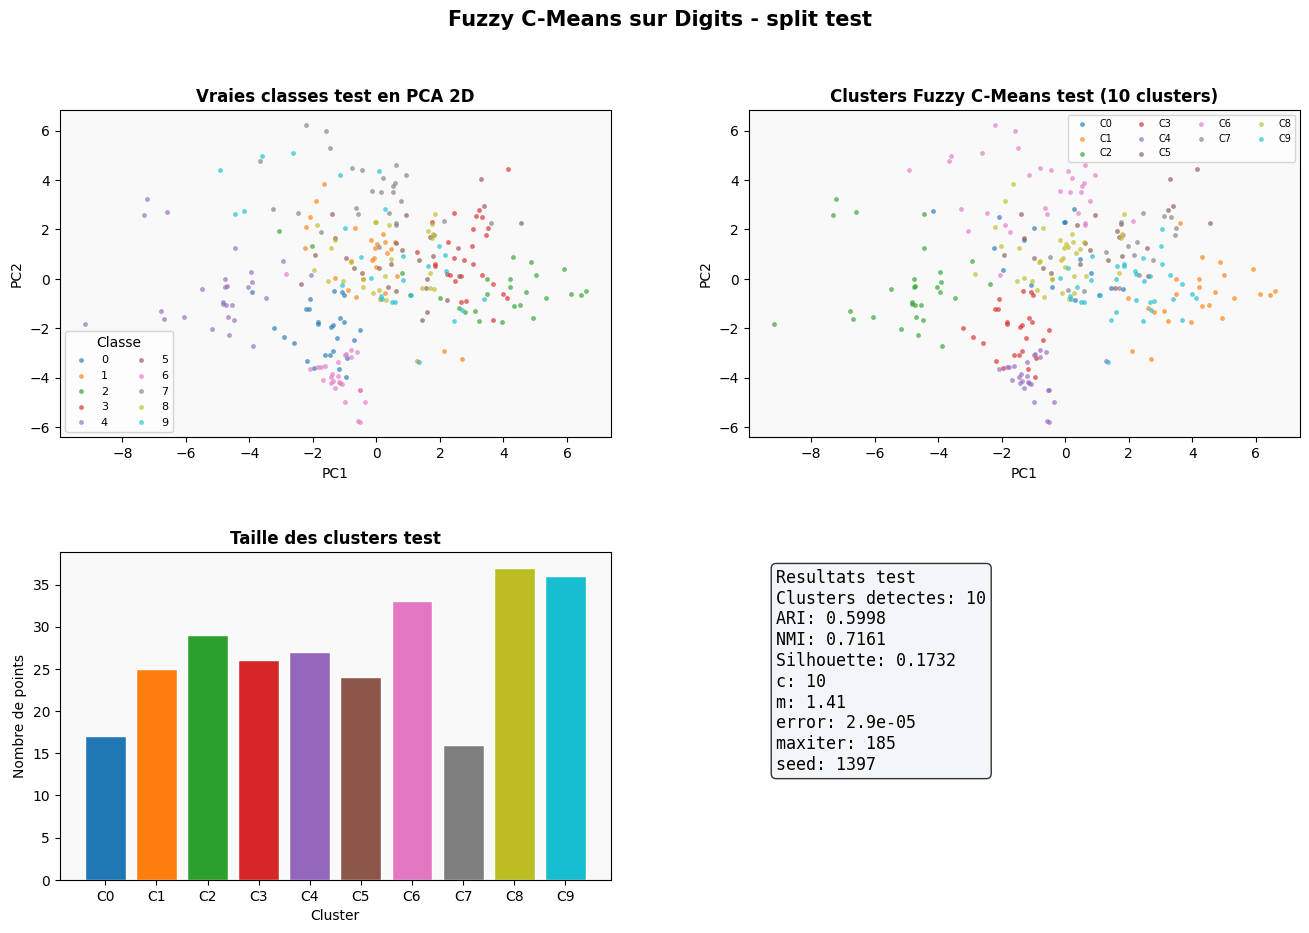

In [5]:
# Visualisation des resultats du split test
if 'labels_test' not in globals():
    print('Les labels du test ne sont pas encore calcules. Execute d abord la cellule de test final.')
else:
    pred_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    unique_pred = np.unique(labels_test)

    fig = plt.figure(figsize=(16, 10), facecolor='white')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)

    ax1 = fig.add_subplot(gs[0, 0])
    for cls in np.unique(y_test):
        mask = y_test == cls
        ax1.scatter(X_test_pca2[mask, 0], X_test_pca2[mask, 1], s=12, alpha=0.65, label=str(cls), color=class_colors[cls], linewidths=0)
    ax1.set_title('Vraies classes test en PCA 2D', fontsize=12, fontweight='bold')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.legend(title='Classe', ncol=2, fontsize=8)
    ax1.set_facecolor('#f9f9f9')

    ax2 = fig.add_subplot(gs[0, 1])
    for cid in np.sort(unique_pred):
        mask = labels_test == cid
        ax2.scatter(X_test_pca2[mask, 0], X_test_pca2[mask, 1], s=12, alpha=0.65, label=f'C{cid}', color=pred_colors[cid % 10], linewidths=0)
    ax2.set_title(f'Clusters Fuzzy C-Means test ({len(unique_pred)} clusters)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.legend(ncol=4, fontsize=7)
    ax2.set_facecolor('#f9f9f9')

    ax3 = fig.add_subplot(gs[1, 0])
    counts = np.array([np.sum(labels_test == cid) for cid in np.sort(unique_pred)])
    ax3.bar([f'C{cid}' for cid in np.sort(unique_pred)], counts, color=[pred_colors[cid % 10] for cid in np.sort(unique_pred)], edgecolor='white')
    ax3.set_title('Taille des clusters test', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('Nombre de points')
    ax3.set_facecolor('#f9f9f9')

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    metrics_text = (
        f'Resultats test\n'
        f'Clusters detectes: {len(unique_pred)}\n'
        f'ARI: {test_metrics["ari"]:.4f}\n'
        f'NMI: {test_metrics["nmi"]:.4f}\n'
        f'Silhouette: {test_metrics["silhouette"]:.4f}\n'
        f'c: {best_params["c"]}\n'
        f'm: {best_params["m"]:.2f}\n'
        f'error: {best_params["error"]:.1e}\n'
        f'maxiter: {best_params["maxiter"]}\n'
        f'seed: {best_params["seed"]}'
    )
    ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes, fontsize=12, verticalalignment='top', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8))
    plt.suptitle('Fuzzy C-Means sur Digits - split test', fontsize=15, fontweight='bold')
    plt.show()